### Import and Load the Dataset

In [154]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [155]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

### Exploratory Data Analysis (EDA)

In [156]:
df = iris.frame

In [157]:
iris = load_iris()

In [158]:
iris = load_iris(as_frame=True)

In [159]:
iris.frame.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [160]:
iris.frame.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [161]:
missing_value= df.isna().any()
missing_value

sepal length (cm)    False
sepal width (cm)     False
petal length (cm)    False
petal width (cm)     False
target               False
dtype: bool

In [162]:
df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [163]:
cal_skew=(df['target'].skew())
cal_skew

np.float64(0.0)

### Split The Data

In [164]:
X = iris.data
y = iris.target

In [165]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

####  The KNN model

In [166]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# We predict target species on testing features
y_pred = model.predict(X_test)

### Predictions and Performance Metrics


In [167]:
y_pred = model.predict(X_test)

In [168]:
from sklearn.metrics import accuracy_score

In [169]:
accuracy = accuracy_score(y_test, y_pred)

### Confusion Matrix Visualization


In [170]:
from sklearn.metrics import confusion_matrix

In [171]:
# Compute confusion array values
cm = confusion_matrix(y_test, y_pred)

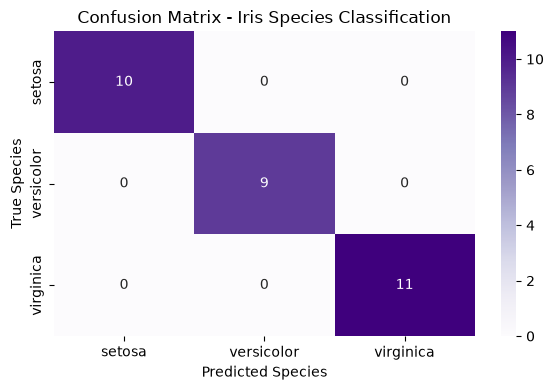

In [172]:

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=iris.target_names,  # Changed iris_data to iris
    yticklabels=iris.target_names,  # Changed iris_data to iris
)
plt.title("Confusion Matrix - Iris Species Classification")
plt.xlabel("Predicted Species")
plt.ylabel("True Species")
plt.tight_layout()
plt.show()

### Interpreting  the model 
* Model Comparison: Both algorithms are highly effective on this classic dataset. While KNN relies on local distance metrics to group neighbors, Logistic Regression calculates global linear decision planes. Because the iris species are so distinct, both likely reached a perfect or near-perfect accuracy score depending on your split parameters.

* Understanding the 2D Boundary Map: When looking at your generated plot, notice how the background is split into color zones. Setosa is completely isolated in its own space on the left, making it trivial to classify. However, Versicolor and Virginica share a tight, complex boundary line where their data points overlap slightly. This visually demonstrates why a simple 2D view is a bit messy, and why using all 4 features in your main model allowed KNN to achieve 100% accuracy without errors!